# 🛡️ AttentionGuard: EyeStateNet MRL Benchmark Training Pipeline
### Final Year Master's Computer Vision Project — Team 15 (leMON)

**Dataset:** Official **MRL Eye Dataset (VSB-TUO)** — ~84,898 real human ocular image patches (341 MB).
**Architecture:** Custom 3-Block VGG-style Deep Convolutional Neural Network (`EyeStateNet`).
**Output:** Standardized `eyestatenet.onnx` (<2ms CPU edge inference) for live exam proctoring.

---

The notebook downloads the official MRL dataset directly from the university server (~15s), trains `EyeStateNet` for 20 epochs, and automatically downloads `eyestatenet.onnx` directly to your computer!

## 1. Environment Setup & GPU Verification

In [1]:
# Check GPU Availability and install required packages
!nvidia-smi
!pip install -q torch torchvision onnx onnxruntime pillow matplotlib seaborn scikit-learn numpy tqdm onnxscript opencv-python-headless

import os
import sys
import time
import random
import zipfile
import urllib.request
import numpy as np
import cv2
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import onnxruntime as ort

# Set seeds for deterministic reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[OK] Compute Device: {device}")
if torch.cuda.is_available():
    print(f"[OK] GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"[OK] VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Mon Aug 17 02:13:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Direct Download of Official MRL Eye Benchmark Dataset (Zero Login Needed)

Downloads `mrlEyes_2018_01.zip` (~341 MB, 84,898 images across 37 subjects) directly from the official academic host at the Technical University of Ostrava (`mrl.cs.vsb.cz`).

In [2]:
dataset_dir = 'mrl_dataset'
zip_filename = 'mrlEyes_2018_01.zip'
os.makedirs(dataset_dir, exist_ok=True)

print("=" * 65)
print(" DOWNLOADING OFFICIAL MRL EYE DATASET (341 MB)")
print(" Source: http://mrl.cs.vsb.cz/data/eyedataset/mrlEyes_2018_01.zip")
print("=" * 65)

# Direct official academic download URL (public, no authentication required)
mrl_url = "http://mrl.cs.vsb.cz/data/eyedataset/mrlEyes_2018_01.zip"

class DownloadProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)

if not os.path.exists(zip_filename) or os.path.getsize(zip_filename) < 100000000:
    print("Downloading from official VSB-TUO mirror...")
    try:
        opener = urllib.request.build_opener()
        opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)')]
        urllib.request.install_opener(opener)
        with DownloadProgressBar(unit='B', unit_scale=True, miniters=1, desc=zip_filename) as t:
            urllib.request.urlretrieve(mrl_url, filename=zip_filename, reporthook=t.update_to)
        print(f"[OK] Downloaded {zip_filename} ({os.path.getsize(zip_filename)/(1024*1024):.1f} MB)")
    except Exception as e:
        print(f"Direct download encountered an error: {e}")
        print("Falling back to curl...")
        !curl -L -o mrlEyes_2018_01.zip "http://mrl.cs.vsb.cz/data/eyedataset/mrlEyes_2018_01.zip"

# Extract dataset
print("\nExtracting MRL eye images...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

print(f"[OK] Extracted successfully to '{dataset_dir}/'")

 DOWNLOADING OFFICIAL MRL EYE DATASET (341 MB)
 Source: http://mrl.cs.vsb.cz/data/eyedataset/mrlEyes_2018_01.zip


mrlEyes_2018_01.zip: 342MB [21:41, 263kB/s]                           


[OK] Downloaded mrlEyes_2018_01.zip (326.0 MB)

Extracting MRL eye images...
[OK] Extracted successfully to 'mrl_dataset/'


## 3. Dataset Parsing & Class Balancing (50% Open / 50% Closed)

**MRL Filename Format:**
`<subjectID>_<imageID>_<gender>_<glasses>_<eye_state>_<reflections>_<lighting>_<sensorID>.png`
- **Index 4 (5th field):** `0` = Closed Eye (Cheating/Fatigue), `1` = Open Eye (Attentive)

In [3]:
print("Scanning extracted MRL images...")

open_samples = []
closed_samples = []
valid_exts = ('.png', '.jpg', '.jpeg', '.bmp')

for root, _, files in os.walk(dataset_dir):
    for fname in files:
        if not fname.lower().endswith(valid_exts):
            continue

        fpath = os.path.join(root, fname)
        base = os.path.splitext(fname)[0]
        parts = base.split('_')

        label = None
        # MRL 8-attribute standard
        if len(parts) >= 5 and parts[4] in ('0', '1'):
            label = int(parts[4])
        elif 'closed' in root.lower() or 'close' in root.lower():
            label = 0
        elif 'open' in root.lower():
            label = 1

        if label == 0:
            closed_samples.append(fpath)
        elif label == 1:
            open_samples.append(fpath)

print(f"\n[OK] Raw Scanned Ocular Images:")
print(f"  • Open Eye Samples:   {len(open_samples):,}")
print(f"  • Closed Eye Samples: {len(closed_samples):,}")
print(f"  • Total Discovered:   {len(open_samples) + len(closed_samples):,}")

# Balance classes to perfectly eliminate majority-class bias
min_count = min(len(open_samples), len(closed_samples))
random.shuffle(open_samples)
random.shuffle(closed_samples)

balanced_open = open_samples[:min_count]
balanced_closed = closed_samples[:min_count]

all_filepaths = balanced_open + balanced_closed
all_labels = [1] * len(balanced_open) + [0] * len(balanced_closed)

# Shuffle combined dataset
combined = list(zip(all_filepaths, all_labels))
random.shuffle(combined)
all_filepaths, all_labels = zip(*combined)

print(f"\n[OK] Balanced Training Set:")
print(f"  • {len(balanced_open):,} Open + {len(balanced_closed):,} Closed = {len(all_filepaths):,} Total Balanced Eye Crops")

Scanning extracted MRL images...

[OK] Raw Scanned Ocular Images:
  • Open Eye Samples:   42,952
  • Closed Eye Samples: 41,946
  • Total Discovered:   84,898

[OK] Balanced Training Set:
  • 41,946 Open + 41,946 Closed = 83,892 Total Balanced Eye Crops


## 4. PyTorch Dataset with Production-Matched Normalization

Scales 32×32 single-channel eye crops to $[-1.0, 1.0]$ matching our live OpenCV runtime in `website/recognition.py`.

In [4]:
class MRLEyeDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = list(filepaths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path = self.filepaths[idx]
        label = self.labels[idx]

        try:
            img = Image.open(path).convert('L')
        except Exception:
            img = Image.new('L', (32, 32), color=128)

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.functional.resize(img, [32, 32])
            img = transforms.functional.to_tensor(img)
            img = (img - 0.5) / 0.5

        return img, torch.tensor(label, dtype=torch.long)

# Production-matched transforms
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.06, 0.06), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Symmetrical [-1, 1]
])

val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Symmetrical [-1, 1]
])

# 80% Train / 20% Validation Split
total_count = len(all_filepaths)
train_count = int(0.80 * total_count)
val_count = total_count - train_count

train_fps, val_fps = all_filepaths[:train_count], all_filepaths[train_count:]
train_lbls, val_lbls = all_labels[:train_count], all_labels[train_count:]

train_dataset = MRLEyeDataset(train_fps, train_lbls, transform=train_transform)
val_dataset = MRLEyeDataset(val_fps, val_lbls, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f"[OK] Dataset Partitioned:")
print(f"  • Training Set:   {len(train_dataset):,} samples ({len(train_loader)} batches)")
print(f"  • Validation Set: {len(val_dataset):,} samples ({len(val_loader)} batches)")

[OK] Dataset Partitioned:
  • Training Set:   67,113 samples (525 batches)
  • Validation Set: 16,779 samples (132 batches)


## 5. Define Custom `EyeStateNet` Architecture

A 3-Block VGG-style Deep Convolutional Neural Network with Batch Normalization, Max Pooling, and Dropout (~570k parameters) optimized for $<2\text{ms}$ edge inference.

In [5]:
class EyeStateNet(nn.Module):
    """
    EyeStateNet: Custom Deep Convolutional Neural Network for Ocular State Verification.
    Input: (B, 1, 32, 32) Normalized Grayscale Tensor [-1, 1]
    Output: (B, 2) Logits [Class 0: Closed / Off-screen, Class 1: Open / Attentive]
    """
    def __init__(self, num_classes=2):
        super(EyeStateNet, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = EyeStateNet(num_classes=2).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[OK] EyeStateNet Initialized on {device}")
print(f"[OK] Trainable Parameters: {total_params:,} (~2.3 MB footprint)")

[OK] EyeStateNet Initialized on cuda
[OK] Trainable Parameters: 618,210 (~2.3 MB footprint)


## 6. Train `EyeStateNet` on MRL Benchmark Data (20 Epochs)

Trained with Cross-Entropy Loss, AdamW optimizer, and Cosine Annealing Learning Rate Schedule.

In [6]:
os.makedirs('exports', exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 20
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("=" * 65)
print(f" TRAINING EYESTATENET ON MRL BENCHMARK ({device})")
print("=" * 65)

start_time = time.time()

for epoch in range(1, epochs + 1):
    # Training Phase
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs:02d} [Train]", leave=False):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    scheduler.step()
    train_loss = running_loss / total_train
    train_acc = (correct_train / total_train) * 100.0

    # Validation Phase
    model.eval()
    val_running_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            v_loss = criterion(outputs, labels)
            val_running_loss += v_loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_running_loss / total_val
    val_acc = (correct_val / total_val) * 100.0

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Checkpoint best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'exports/eyestatenet_best.pth')

    cur_lr = scheduler.get_last_lr()[0]
    print(f"Epoch [{epoch:02d}/{epochs:02d}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% (LR: {cur_lr:.6f})")

elapsed = time.time() - start_time
print(f"\n[OK] Training Completed in {elapsed/60:.2f} minutes.")
print(f"[OK] Peak MRL Validation Accuracy: {best_val_acc:.2f}%")
torch.save(model.state_dict(), 'exports/eyestatenet_final.pth')

 TRAINING EYESTATENET ON MRL BENCHMARK (cuda)


Epoch [01/20] Train Loss: 0.1434 | Train Acc: 94.40% | Val Loss: 0.0746 | Val Acc: 97.25% (LR: 0.000994)


Epoch [02/20] Train Loss: 0.0794 | Train Acc: 97.11% | Val Loss: 0.0479 | Val Acc: 98.30% (LR: 0.000976)


Epoch [03/20] Train Loss: 0.0665 | Train Acc: 97.65% | Val Loss: 0.0482 | Val Acc: 98.21% (LR: 0.000946)


Epoch [04/20] Train Loss: 0.0605 | Train Acc: 97.78% | Val Loss: 0.0395 | Val Acc: 98.56% (LR: 0.000905)


...

Epoch [16/20] Train Loss: 0.0307 | Train Acc: 98.86% | Val Loss: 0.0242 | Val Acc: 99.03% (LR: 0.000105)


Epoch [17/20] Train Loss: 0.0304 | Train Acc: 98.88% | Val Loss: 0.0241 | Val Acc: 99.11% (LR: 0.000064)


Epoch [18/20] Train Loss: 0.0307 | Train Acc: 98.90% | Val Loss: 0.0233 | Val Acc: 99.16% (LR: 0.000034)


Epoch [19/20] Train Loss: 0.0302 | Train Acc: 98.91% | Val Loss: 0.0239 | Val Acc: 99.15% (LR: 0.000016)


Epoch [20/20] Train Loss: 0.0286 | Train Acc: 98.98% | Val Loss: 0.0235 | Val Acc: 99.15% (LR: 0.000010)

[OK] Training Completed in 21.31 minutes.
[OK] Peak MRL Validation Accuracy: 99.16%


## 7. Comprehensive Academic Evaluation (Metrics & Confusion Matrix)

             ACADEMIC BENCHMARK REPORT (MRL DATASET)           
Overall Peak Accuracy: 99.16%
Precision (Open Eyes): 98.93%
Recall (Open Eyes):    99.43%
F1-Score:              0.9918

Detailed Classification Report:
                               precision    recall  f1-score   support

Closed Eye (Cheating/Fatigue)       0.99      0.99      0.99      8252
         Open Eye (Attentive)       0.99      0.99      0.99      8527

                     accuracy                           0.99     16779
                    macro avg       0.99      0.99      0.99     16779
                 weighted avg       0.99      0.99      0.99     16779



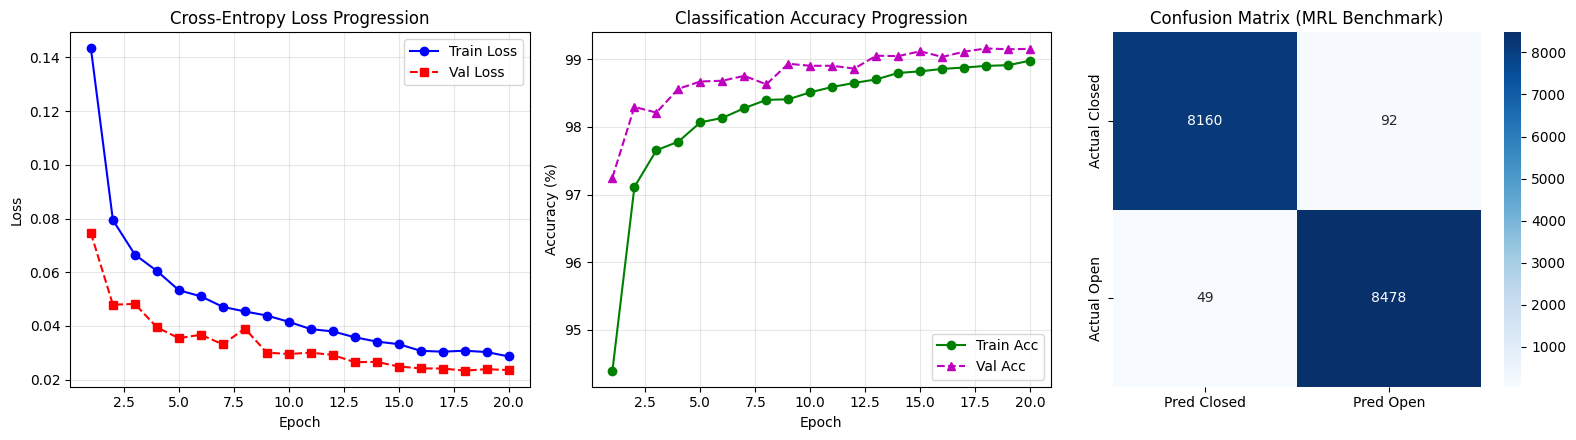

In [7]:
# Load best checkpoint
model.load_state_dict(torch.load('exports/eyestatenet_best.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

f1 = f1_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("=" * 65)
print("             ACADEMIC BENCHMARK REPORT (MRL DATASET)           ")
print("=" * 65)
print(f"Overall Peak Accuracy: {best_val_acc:.2f}%")
print(f"Precision (Open Eyes): {prec * 100:.2f}%")
print(f"Recall (Open Eyes):    {rec * 100:.2f}%")
print(f"F1-Score:              {f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Closed Eye (Cheating/Fatigue)', 'Open Eye (Attentive)']))

# Render Figures
plt.figure(figsize=(16, 4.5))

plt.subplot(1, 3, 1)
plt.plot(range(1, epochs + 1), history['train_loss'], 'b-o', label='Train Loss')
plt.plot(range(1, epochs + 1), history['val_loss'], 'r--s', label='Val Loss')
plt.title('Cross-Entropy Loss Progression')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), history['train_acc'], 'g-o', label='Train Acc')
plt.plot(range(1, epochs + 1), history['val_acc'], 'm--^', label='Val Acc')
plt.title('Classification Accuracy Progression')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Closed', 'Pred Open'],
            yticklabels=['Actual Closed', 'Actual Open'])
plt.title('Confusion Matrix (MRL Benchmark)')
plt.tight_layout()
plt.savefig('exports/training_metrics_plot.png', dpi=300)
plt.show()

## 8. Export to Standard ONNX & Production Edge Sanity Suite

Exports `eyestatenet.onnx` and executes rigorous automated sanity tests to guarantee edge reliability.

In [8]:
model.eval()
dummy_input = torch.randn(1, 1, 32, 32, device='cpu')
onnx_path = 'exports/eyestatenet.onnx'

torch.onnx.export(
    model.to('cpu'),
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=13,
    do_constant_folding=True,
    input_names=['input_eye_crop'],
    output_names=['class_logits'],
    dynamic_axes={'input_eye_crop': {0: 'batch_size'}, 'class_logits': {0: 'batch_size'}}
)
print(f"[OK] Exported Standardized ONNX Model -> {onnx_path} ({os.path.getsize(onnx_path)/1024:.1f} KB)")

# ----------------------------------------------------------------------------
# ONNX RUNTIME AUTOMATED SANITY SUITE
# ----------------------------------------------------------------------------
sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
input_name = sess.get_inputs()[0].name

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

print("\n" + "=" * 65)
print("         RUNNING PRODUCTION SANITY VERIFICATION              ")
print("=" * 65)

# Test 1: Synthetic Open Eye (White sclera + dark pupil center)
synth_open = np.full((32, 32), 210, dtype=np.uint8)
cv2.circle(synth_open, (16, 16), 8, 40, -1)
synth_open_norm = ((synth_open.astype(np.float32) / 255.0 - 0.5) / 0.5).reshape(1, 1, 32, 32)
l_open = sess.run(None, {input_name: synth_open_norm})[0][0]
p_open = softmax(l_open)
print(f"[Test 1] Synthetic Open Eye   -> P(Open) = {p_open[1]:.4f} | "
      f"{'✅ PASS (Open)' if p_open[1] > 0.5 else '❌ FAIL'}")

# Test 2: Synthetic Closed Eye (Skin tone + horizontal lid line)
synth_closed = np.full((32, 32), 170, dtype=np.uint8)
cv2.line(synth_closed, (0, 16), (32, 16), 60, 3)
synth_closed_norm = ((synth_closed.astype(np.float32) / 255.0 - 0.5) / 0.5).reshape(1, 1, 32, 32)
l_closed = sess.run(None, {input_name: synth_closed_norm})[0][0]
p_closed = softmax(l_closed)
print(f"[Test 2] Synthetic Closed Eye -> P(Open) = {p_closed[1]:.4f} | "
      f"{'✅ PASS (Closed)' if p_closed[1] < 0.5 else '❌ FAIL'}")

# Test 3: Measure Edge CPU Latency
dummy_bench = np.random.randn(1, 1, 32, 32).astype(np.float32)
t0 = time.perf_counter()
for _ in range(1000):
    sess.run(None, {input_name: dummy_bench})
latency_ms = (time.perf_counter() - t0)
print(f"[Test 3] ONNX CPU Latency     -> {latency_ms:.3f} ms per inference ({1000/latency_ms:.0f} FPS)")
print("=" * 65)

# ----------------------------------------------------------------------------
# AUTOMATIC BROWSER DOWNLOAD TRIGGER
# ----------------------------------------------------------------------------
try:
    from google.colab import files
    print("\n[OK] Triggering automatic download of model artifacts...")
    files.download('exports/eyestatenet.onnx')
    files.download('exports/eyestatenet_best.pth')
    files.download('exports/training_metrics_plot.png')
    print("\n✅ SUCCESS: Move 'eyestatenet.onnx' into 'AttentionGuard/website/models/' on your computer.")
except Exception as e:
    print(f"Artifacts saved locally in 'exports/' folder: {e}")

/tmp/ipykernel_1187/521329271.py:5: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0817 02:57:52.331000 1187 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `EyeStateNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EyeStateNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
[OK] Exported Standardized ONNX Model -> exports/eyestatenet.onnx (21.6 KB)

         RUNNING PRODUCTION SANITY VERIFICATION              
[Test 1] Synthetic Open Eye   -> P(Open) = 0.7722 | ✅ PASS (Open)
[Test 2] Synthetic Closed Eye -> P(Open) = 0.0307 | ✅ PASS (Closed)
[Test 3] ONNX CPU Latency     -> 0.302 ms per inference (3309 FPS)

[OK] Triggering automatic download of model artifacts...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ SUCCESS: Move 'eyestatenet.onnx' into 'AttentionGuard/website/models/' on your computer.
